# ⚙️ Dataprocessing of datasets
This notebook filters GTEx and TCGA expression data to include only **pancreas samples**, keeping gene identifiers and harmonizing formats for downstream CSD-analyzing.

**Goal:** Load, clean, normalize, transform and prepare RNA-seq data for multi-omics integration (CSD network analysis)

## Imports and files
Imports needed for all data processing:

In [1]:
import pandas as pd 
import numpy as np
import os
from pathlib import Path
import gzip
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.pylab import normal
from functools import reduce
from random import sample
import re


In [2]:
# Directory paths
DATA_DIR = Path("../../data/raw/")
OUT_DIR = Path("../../data/processed/")
RESULT_DIR = Path("../../results/")

# Raw data
gtex_gct = DATA_DIR / "gtex/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct"
gtex_meta = DATA_DIR / "gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt"
tcga_manifest = DATA_DIR / "tcga/manifest_filtered.txt"
tcga_counts_dir = DATA_DIR / "tcga/"

# Processed data output paths
gtex_output_path = OUT_DIR / "gtex/gtex_pancreas_processed.csv"
tcga_output_path = OUT_DIR / "tcga/tcga_pancreas_processed.csv"

# Paths for data integration
gtf_path = DATA_DIR / "gencode/gencode.v26.annotation.gtf.gz"
gtex_out_int = OUT_DIR / "gtex/gtex_int.csv"
tcga_out_int = OUT_DIR / "tcga/tcga_int.csv"
mapping_file = OUT_DIR / "genelist/common_protein_coding_genes.txt"
proteome_common_genes = OUT_DIR / "genelist/proteome_common_genes.txt"

# Paths for transformation
gtex_log_out = OUT_DIR / "gtex/gtex_log2.csv"
tcga_log_out = OUT_DIR / "tcga/tcga_log2.csv"
pca_before_log = RESULT_DIR / "figures/pca_before_log2.png"
pca_after_log = RESULT_DIR / "figures/pca_after_log2.png"

# Paths for batch correction
out_gtex_combat = OUT_DIR / "gtex/gtex_combat.csv"
out_tcga_combat = OUT_DIR / "tcga/tcga_combat.csv"

# Paths for final file
out_gtex_final = OUT_DIR / "rna_healthy.txt"
out_tcga_final = OUT_DIR / "rna_cancer.txt"

## Helper functions

### Load functions:


In [3]:



def load_gtex(gtex_meta, gtex_gct):

    # 1. Load metadata to find pancreas sample
    meta = pd.read_csv(gtex_meta, sep="\t")
    pancreas_ids = meta.loc[meta["SMTS"] == "Pancreas", "SAMPID"].tolist()
    if not pancreas_ids:
        raise ValueError('Ingen pancreas-samples funnet i GTEx metadata.')
    print(f"Found {len(pancreas_ids)} pancreas samples in GTEx metadata.")

    # 2. Read GTEx expression data (skipping first two rows) (only header)
    header = pd.read_csv(gtex_gct, sep="\t", skiprows=2, nrows = 0)
    header.columns = header.columns.str.strip()

    all_cols = header.columns.tolist()

    # 3. Identify the gene_id column 
    gene_col = "Name" if "Name" in all_cols else all_cols[0]

    # 4. select only gene_id + pancreas samples
    keep_cols = [gene_col] + [c for c in all_cols if c in pancreas_ids]
    print(f"Loading only {len(keep_cols)-1} pancreas column")

    # 5. Load only selected columns
    expr = pd.read_csv(gtex_gct, sep = "\t", skiprows=2, usecols=keep_cols)
    print(f"Loaded GTEx subset with shape: {expr.shape}")

    expr = expr.rename(columns={gene_col: "gene_id"})

    return expr


def load_tcga_tpm(filepath, value_col="tpm_unstranded"):
    """
    Load a TCGA STAR gene counts file into a pandas Series.
    Default: tpm_unstranded.
    """
    df = pd.read_csv(filepath, sep="\t", comment="#", header=0)

    # Drop QC rows (N_unmapped, N_multimapping, etc.)
    first_col = df.columns[0]
    df = df[~df[first_col].astype(str).str.startswith(("N_", "__"))]
    

    # Use first column (gene_id) as index
    df = df[[first_col, value_col]]

    df = df.rename(columns={first_col: "gene_id"})

    return df


def process_tcga_data(counts_dir, value_col="tpm_unstranded"):
    
    all_samples = [] # Dictionary to hold sample data
    input_dir = Path(counts_dir) # Path to TCGA counts directory

    print(f"Searching for STAR counts files in {input_dir}")
    print(f"Using column '{value_col}' for expression values.")

    # Loop throug all .tsv files cotaining STAR counts
    for fpath in input_dir.rglob("*.tsv"):
        if "star_gene_counts" in fpath.name:
            sample_id = fpath.name.split(".")[0]
            df = load_tcga_tpm(fpath, value_col=value_col)
            df = df.rename(columns={value_col: sample_id})
            all_samples.append(df)
    if not all_samples:
        raise RuntimeError("No TCGA STAR counts files found in the specified directory.")
    print(f"Loaded {len(all_samples)} TCGA samples.")
    
    # Combine all samples into a single DataFrame
    
    tcga = reduce(
    lambda left, right: pd.merge(left, right, on="gene_id", how="inner"),
    all_samples
)
    print(f"Combined TCGA data shape: {tcga.shape}")
    
    return tcga

### Reuseble functions

In [7]:
# Clean processed datasets

def clean_df(df):

    # Ensure 'gene_id' column exists
    if 'gene_id' not in df.columns:
        raise ValueError("Input DataFrame must contain 'gene_id' column.")

    print(f"Original data shape: {df.shape}")
    
    # Remove version numbers from gene IDs
    df['gene_id'] = df['gene_id'].astype(str).str.split('.').str[0]

    # Remove duplicates
    before = df.shape[0]
    df = df.drop_duplicates(subset='gene_id', keep= 'first')
    removed = before - df.shape[0]
    print(f"Removed {removed} duplicate genes.")
    print(f"Data shape after removing duplicates: {df.shape}")

    # Sort by gene_id
    df_sort = df.sort_values('gene_id').reset_index(drop=True)

    return df_sort

def load_protein_coding_genes(gtf_path, out_file=None):
    
    gene_ids = set()
    records = []

    # Precompile regex patterns for efficiency
    gene_id_pattern = re.compile(r'gene_id "([^"]+)"')
    gene_name_pattern = re.compile(r'gene_name "([^"]+)"')
    biotype_pattern = re.compile(r'gene_type "([^"]+)"|gene_biotype "([^"]+)"')

    with gzip.open(gtf_path, 'rt') as file:
        for line in file:

            if line.startswith('#'):
                continue

            fields = line.strip().split('\t')

            if fields[2] != 'gene':
                continue

            info = fields[8]

            # extract biotype
            biotype_match = biotype_pattern.search(info)
            if not biotype_match:
                continue
            if biotype_match.group(1) != "protein_coding":
                continue
            
            # extract gene_id
            gene_id_match = gene_id_pattern.search(info)
            if not gene_id_match:
                continue
            gene_id = gene_id_match.group(1).split(".")[0]

            # extract gene_name
            gene_name_match = gene_name_pattern.search(info)
            gene_name = gene_name_match.group(1) if gene_name_match else None

            gene_ids.add(gene_id)
            records.append((gene_id, gene_name))
                

    df = pd.DataFrame(records, columns=["gene_id", "gene_name"]).drop_duplicates()

    print(f"Extracted {len(gene_ids)} protein-coding genes from {Path(gtf_path)}")

    if out_file:
        df.to_csv(out_file, index=False)
        print(f"Saved gene ID to name mapping to {out_file}")

    return gene_ids, df

def filter_protein_coding(df, pc_genes, id_col='gene_id'):
    """
    Filter a DataFrame to only protein-coding genes.
    pc_genes should be a Python set of gene IDs (e.g., from load_protein_coding_genes(...)[0]).
    Returns a DataFrame sorted by id_col with index reset.
    """
    if id_col not in df.columns:
        raise ValueError(f"Input DataFrame must contain '{id_col}' column.")
    # pc_genes is a set, so use .isin(pc_genes) directly
    df_filt = df[df[id_col].astype(str).isin(pc_genes)].copy()
    df_filt = df_filt.sort_values(by=id_col).reset_index(drop=True)
    print(f"Filtered to protein-coding genes: {df_filt.shape}")
    return df_filt

def harmonize_datasets(gtex_df, tcga_df, proteome_genes):

    id_col = "gene_id"

    # If user provided a path, load it
    if isinstance(proteome_genes, (str, Path)):
        proteome_genes = pd.read_csv(proteome_genes, header=None)[0].tolist()

    # Find common genes
    common_genes = (set(gtex_df[id_col]) &
                    set(tcga_df[id_col]) &
                    set(proteome_genes)
                    )
    
    print(f"Number of common protein-coding genes: {len(common_genes)}")
        
    #Filter both datasets
    gtex_filt = gtex_df[gtex_df[id_col].isin(common_genes)]
    tcga_filt = tcga_df[tcga_df[id_col].isin(common_genes)]

    with open(OUT_DIR /"genelist/common_genes.txt", "w") as f:
        for gene in common_genes:
            f.write(str(gene) + "\n")

    # Sort both datasets by gene_id to ensure same order
    gtex_filt = gtex_filt.sort_values(by=id_col).reset_index(drop=True)
    tcga_filt = tcga_filt.sort_values(by=id_col).reset_index(drop=True)

    print(f"Shapes after filtering to common genes - GTEx: {gtex_filt.shape}, TCGA: {tcga_filt.shape}")

    return gtex_filt, tcga_filt



def remove_zero_exp_30(df):
    expr_cols = [col for col in df.columns if col != 'gene_id']
    expr_num =df[expr_cols].apply(pd.to_numeric, errors='coerce')
    mask = (expr_num.fillna(0) == 0).mean(axis=1) <= 0.3
    df_clean = df[mask]
    print(f"Removed genes with >30% zero expression, resulting in {df_clean.shape[0]} genes.")
    return df_clean

def log2_transform(input_df):

    if "gene_id" in input_df.columns:
        id_cols = "gene_id"
    else:
        raise ValueError("Input DataFrame must contain 'gene_id' column.")
    
    
    # Split and transform 
    genes = input_df[id_cols]
    expr_values = input_df.drop(columns=[id_cols])

    print("Applying log2(x+1) transformation...")
    transformed_values = np.log2(expr_values + 1)

    transformed_values = pd.concat([genes, transformed_values], axis=1)

    

    return transformed_values

# PCA plot before and after two dataframes

def plot_pca(df_gtex, df_tcga, title, ax=None):

    # Expect genes as rows, samples as columns; require Axes object
    if ax is None:
        raise ValueError('An Axes object must be provided (use subplots).')

    # Drop gene_id column if present (we only want numeric sample columns)
    if 'gene_id' in df_gtex.columns:
        df_gtex = df_gtex.drop(columns=['gene_id'])
    if 'gene_id' in df_tcga.columns:
        df_tcga = df_tcga.drop(columns=['gene_id'])

    # Sanity checks
    if df_gtex.empty or df_tcga.empty:
        raise ValueError('One of the input DataFrames is empty after preprocessing.')

    # Combine datasets along genes then transpose (samples as rows)
    combined_df = pd.concat([df_gtex, df_tcga], axis=1)
    combined_df = combined_df.T
    combined_df = combined_df.fillna(0)

    # Standardize features (genes)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(combined_df)

    # PCA to 2 components
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(scaled_data)

    # Build labels: number of columns == number of samples per dataset
    labels = (['GTEx'] * df_gtex.shape[1]) + (['TCGA'] * df_tcga.shape[1])

    # Calculate percentage of variance explained
    variance_ratio = pca.explained_variance_ratio_
    pc1_var = variance_ratio[0] * 100
    pc2_var = variance_ratio[1] * 100

    print(variance_ratio)

    # Plot each dataset separately (indent scatter inside loop)
    for lab in sorted(set(labels)):
        mask = [l == lab for l in labels]
        ax.scatter(pcs[mask, 0], pcs[mask, 1], label=lab, alpha=0.7, s=20)

    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pc1_var:.2f}%)')
    ax.set_ylabel(f'PC2 ({pc2_var:.2f}%)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
def batch_correction(gtex_df, tcga_df):

    print(f"{gtex_df.shape[0]} genes and {gtex_df.shape[1]-1} GTEx samples")
    print(f"{tcga_df.shape[0]} genes and {tcga_df.shape[1]-1} TCGA samples")

    # ensure same gene order
    if not gtex_df['gene_id'].equals(tcga_df['gene_id']):
        raise ValueError("Gene IDs do not match between GTEx and TCGA datasets.")
    print("Gene IDs match. Proceeding with batch correction.")

    # Combine datasets
    combined_df = pd.concat([gtex_df, tcga_df.drop(columns=['gene_id'])], axis=1)
    genes = combined_df['gene_id'].astype(str)
    expr_values = combined_df.drop(columns=['gene_id']).astype(float)
    

    # Create batch labels
    n_gtex = gtex_df.shape[1] - 1  # Exclude gene_id column
    n_tcga = tcga_df.shape[1] - 1
    batch_labels = [0] * n_gtex + [1] * n_tcga
    print(f"Performing batch correction on {expr_values.shape[1]} samples...")

    # Convert to AnnData
    adata = sc.AnnData(expr_values.T)
    adata.var_names = genes
    adata.obs['batch'] = batch_labels
    adata.obs_names = expr_values.columns

    # Run ComBat batch correction
    sc.pp.combat(adata, key='batch')

    # Extract corrected data
    expr_corrected = pd.DataFrame(adata.X.T, columns=adata.obs_names)
    expr_corrected.insert(0, 'gene_id', genes)

    # Split back into GTEx and TCGA
    gtex_corrected = expr_corrected[['gene_id'] + list(gtex_df.columns[1:])]
    tcga_corrected = expr_corrected[['gene_id'] + list(tcga_df.columns[1:])]


    return gtex_corrected, tcga_corrected


# Z-score normalization for all genes in the correlation matrix
def Z_transform(df, id_col="gene_id"):
    "Apply Z-score normalization for each gene across all samples"
    gene_ids = df[id_col]

    expr_values = df.drop(columns=[id_col]).apply(pd.to_numeric, errors='coerce')

    mean = expr_values.mean(axis=1)
    std = expr_values.std(axis=1)
    Z = (expr_values.sub(mean, axis=0)).div(std, axis=0)
    Z[id_col] = gene_ids

    # Reorder columns to have gene_id first
    Z = Z[[id_col] + [col for col in Z.columns if col != id_col]]

    # Remove header 
    print("Applied Z-transformation.")
    return Z

## Main pipeline

### Load and clean data



From raw data to clean .csv datasets:

GTEX raw tpm -> GTEX only pancreas genes -> 

In [5]:
# Process GTEx data
gtex_raw = load_gtex(gtex_meta, gtex_gct)


Found 360 pancreas samples in GTEx metadata.
Loading only 328 pancreas column
Loaded GTEx subset with shape: (56200, 329)


In [6]:
# Process TCGA data
tcga_raw = process_tcga_data(tcga_counts_dir, value_col="tpm_unstranded")

Searching for STAR counts files in ..\..\data\raw\tcga
Using column 'tpm_unstranded' for expression values.
Loaded 183 TCGA samples.
Combined TCGA data shape: (60660, 184)


In [8]:
# Clean datasets
gtex_clean = clean_df(gtex_raw)
tcga_clean = clean_df(tcga_raw)

Original data shape: (56200, 329)
Removed 44 duplicate genes.
Data shape after removing duplicates: (56156, 329)
Original data shape: (60660, 184)
Removed 44 duplicate genes.
Data shape after removing duplicates: (60616, 184)


### Data integration

In [9]:
# Remove genes with >30% zero expression
gtex_filt = remove_zero_exp_30(gtex_clean)
tcga_filt = remove_zero_exp_30(tcga_clean)

Removed genes with >30% zero expression, resulting in 24565 genes.
Removed genes with >30% zero expression, resulting in 27839 genes.


In [10]:
# Filter out PC genes
pc_genes = load_protein_coding_genes(gtf_path, out_file=mapping_file)[0]
gtex_pc_filt= filter_protein_coding(gtex_filt, pc_genes)
tcga_pc_filt = filter_protein_coding(tcga_filt, pc_genes)

Extracted 19799 protein-coding genes from ..\..\data\raw\gencode\gencode.v26.annotation.gtf.gz
Saved gene ID to name mapping to ..\..\data\processed\genelist\common_protein_coding_genes.txt
Filtered to protein-coding genes: (16496, 329)
Filtered to protein-coding genes: (16998, 184)


In [11]:
# Harmonize genelist
gtex_pc_filt, tcga_pc_filt = harmonize_datasets(gtex_pc_filt, tcga_pc_filt, proteome_common_genes)

Number of common protein-coding genes: 8278
Shapes after filtering to common genes - GTEx: (8278, 329), TCGA: (8278, 184)


### Data Transformation: 

#### Log2-transformation

Gene expression values can span several orders of magnitude.
To stabilize variance and reduce the impact of highly expressed genes, we apply a **log2(x+1)** transformation to both harmonize data

In [12]:


gtex_log = log2_transform(gtex_pc_filt)
tcga_log = log2_transform(tcga_pc_filt)


Applying log2(x+1) transformation...
Applying log2(x+1) transformation...


#### Batch correction

To remove systematic differences between GTEx and TCGA samples that arise from distinct experimental protocols, **Combat** is applied using the `scanpy` implementation. This aligns both datasets while preserving biological variation.

In [13]:
gtex_combat, tcga_combat = batch_correction(gtex_log, tcga_log)

8278 genes and 328 GTEx samples
8278 genes and 183 TCGA samples
Gene IDs match. Proceeding with batch correction.
Performing batch correction on 511 samples...


c:\Users\tiril\anaconda3\envs\master-tiril\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


#### Z-transformation

In [14]:
# Apply Z-transformation to dataset
gtex_z = Z_transform(gtex_log)
tcga_z = Z_transform(tcga_log)

Applied Z-transformation.
Applied Z-transformation.


## Resulting pca plot

[0.5404517  0.06517187]
[0.66401063 0.07324093]
[0.47335385 0.0583152 ]
[0.47291142 0.05792476]


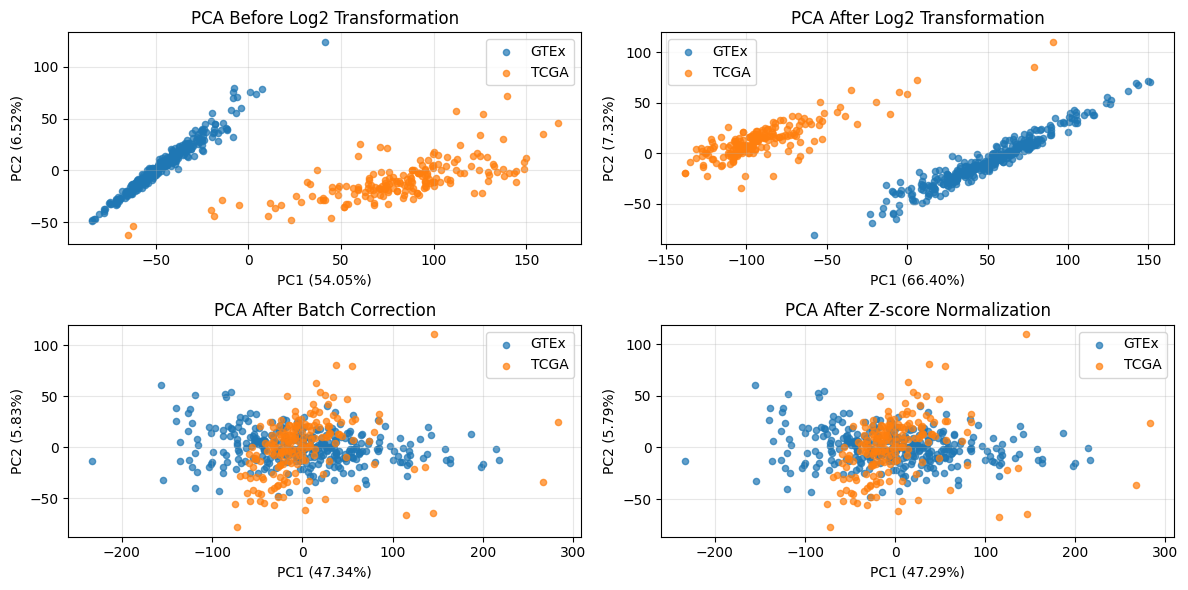

In [15]:
# PCA plots of each step of transformation of datasets
fig, axes = plt.subplots(2, 2, figsize =(12, 6))

plot_pca(gtex_pc_filt.drop(columns=['gene_id']), tcga_pc_filt.drop(columns=['gene_id']),
         title="PCA Before Log2 Transformation", ax=axes[0, 0])
plot_pca(gtex_log.drop(columns=['gene_id']), tcga_log.drop(columns=['gene_id']),
         title="PCA After Log2 Transformation", ax=axes[0, 1])
plot_pca(gtex_combat.drop(columns=['gene_id']), tcga_combat.drop(columns=['gene_id']),
         title="PCA After Batch Correction", ax=axes[1, 0])
plot_pca(gtex_z.drop(columns=['gene_id']), tcga_z.drop(columns=['gene_id']),
         title="PCA After Z-score Normalization", ax=axes[1, 1])
plt.tight_layout()

## Save section

In [ ]:
# Save loaded and processed data
gtex_raw.to_csv(gtex_output_path, index=False)
print(f"Processed GTEx pancreas data saved to {gtex_output_path}")
tcga_raw.to_csv(tcga_output_path, index=False)
print(f"Processed TCGA data saved to {tcga_output_path}")


# Save final dataset 
gtex_z.to_csv(out_gtex_final, header=False, index=False)
print(f"Final dataset for GTEX is saved to {out_gtex_final}")
tcga_z.to_csv(out_tcga_final, header=False, index=False)
print(f"Final dataset for TCGA is saved to {out_tcga_final}")

Processed GTEx pancreas data saved to ..\..\data\processed\gtex\gtex_pancreas_processed.csv
Processed TCGA data saved to ..\..\data\processed\tcga\tcga_pancreas_processed.csv
Final dataset for GTEX is saved to ..\..\data\processed\rna_healthy.txt
Final dataset for TCGA is saved to ..\..\data\processed\rna_cancer.txt


In [20]:
# Converts comma-seperated gene expression file to c++ findcorrvar-compatible format

def prepare_findcorrvar_input(df: pd.DataFrame, out: str = OUT_DIR / "ExpData_rna_Healthy.txt", float_format: str = "{:.6f}"):

    df = pd.read_csv(df, sep=",", header=None)

    genes = df.iloc[:, 0].astype(str).values
    values = df.iloc[:,1:]

    with open(out, "w") as f:
        for gene, row in zip(genes, values.to_numpy()):
            formatted_values = " ".join(float_format.format(v) for v in row)
            f.write(f"{gene} {formatted_values}\n")


prepare_findcorrvar_input(out_gtex_final, out=OUT_DIR / "ExpData_rna_Healthy.txt", float_format="{:.6f}")